In [1]:
import logging
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

logging.basicConfig(
    filename='pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logging.info("Pipeline started")
print("Imports successful")

Imports successful


In [ ]:

try:
    con = duckdb.connect()  

    # CSv to DuckDB
    con.execute("CREATE TABLE games AS SELECT * FROM read_csv_auto('games.csv')")
    con.execute("CREATE TABLE teams AS SELECT * FROM read_csv_auto('teams.csv')")
    con.execute("CREATE TABLE stadiums AS SELECT * FROM read_csv_auto('stadiums.csv')")
    con.execute("CREATE TABLE quarterbacks AS SELECT * FROM read_csv_auto('quarterbacks.csv')")

    # Make sure rows were filtered in properly
    for table in ['games', 'teams', 'stadiums', 'quarterbacks']:
        count = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        print(f"{table}: {count} rows")
        logging.info(f"Loaded {table}: {count} rows")

except Exception as e:
    logging.error(f"Error loading data: {e}")
    raise

games: 2879 rows
teams: 35 rows
stadiums: 56 rows
quarterbacks: 5758 rows


In [3]:
#join all tables for modeling
try:
    query = """
    SELECT
        g.game_id,
        g.season,
        g.week,
        g.result,
        g.spread_line,
        g.total_line,
        g.away_rest,
        g.home_rest,
        (g.home_rest - g.away_rest) AS rest_advantage,
        g.away_moneyline,
        g.home_moneyline,
        g.div_game,
        g.overtime,
        t_home.conference AS home_conference,
        t_home.division AS home_division,
        s.roof,
        s.surface,
        s.avg_temp,
        s.avg_wind

    FROM games g
    LEFT JOIN teams t_home ON g.home_team = t_home.team_id
    LEFT JOIN teams t_away ON g.away_team = t_away.team_id
    LEFT JOIN stadiums s ON g.stadium = s.stadium

    WHERE g.spread_line IS NOT NULL
      AND g.result IS NOT NULL
    """

    df_model = con.execute(query).df()
    print(f"Analytical dataset shape: {df_model.shape}")
    print(df_model.head(3))
    logging.info(f"Analytical dataset created: {df_model.shape}")

except Exception as e:
    logging.error(f"Error in SQL query: {e}")
    raise

Analytical dataset shape: (2879, 19)
           game_id  season  week  result  spread_line  total_line  away_rest  \
0   2014_01_GB_SEA    2014     1      20          4.5        46.5          7   
1   2014_01_NO_ATL    2014     1       3         -3.0        51.0          7   
2  2014_01_CIN_BAL    2014     1      -7          1.0        43.5          7   

   home_rest  rest_advantage  away_moneyline  home_moneyline  div_game  \
0          7               0           205.0          -230.0         0   
1          7               0          -160.0           144.0         1   
2          7               0           102.0          -113.0         1   

   overtime home_conference home_division      roof    surface   avg_temp  \
0         0             NFC      NFC West  outdoors  fieldturf  52.557692   
1         1             NFC     NFC South      dome  fieldturf        NaN   
2         0             AFC     AFC North  outdoors  sportturf  56.470588   

   avg_wind  
0  5.807692  
1       

In [4]:
# Prepare features for modeling
# Analysis rationale: we use spread_line as our benchmark feature,
# then add rest advantage, weather, and game context features
# to test whether they add predictive value beyond Vegas

try:
    # Encode categorical features
    df_model['is_dome'] = df_model['roof'].isin(['dome', 'closed']).astype(int)
    df_model['is_grass'] = (df_model['surface'] == 'grass').astype(int)

    # Fill missing weather with neutral values for dome games
    df_model['avg_temp'] = df_model['avg_temp'].fillna(72.0)
    df_model['avg_wind'] = df_model['avg_wind'].fillna(0.0)

    # Define features and target
    features = [
        'spread_line',      # Vegas benchmark
        'total_line',       # over/under line
        'rest_advantage',   # home_rest minus away_rest
        'div_game',         # divisional matchup flag
        'is_dome',          # stadium roof type
        'is_grass',         # playing surface
        'avg_temp',         # temperature
        'avg_wind',         # wind speed
    ]

    X = df_model[features].copy()
    y = df_model['result'].copy()

    # Sort by season and week for time-based splitting
    df_model_sorted = df_model.sort_values(['season', 'week'])
    X = df_model_sorted[features]
    y = df_model_sorted['result']

    print(f"Features: {features}")
    print(f"X shape: {X.shape}, y shape: {y.shape}")
    logging.info(f"Features prepared: {features}")

except Exception as e:
    logging.error(f"Error in feature preparation: {e}")
    raise

Features: ['spread_line', 'total_line', 'rest_advantage', 'div_game', 'is_dome', 'is_grass', 'avg_temp', 'avg_wind']
X shape: (2879, 8), y shape: (2879,)


In [5]:
# Use TimeSeriesSplit to avoid data leakage across seasons
# Analysis rationale: random splits would leak future game info
# into training data — time-based splits are correct for this domain

try:
    tscv = TimeSeriesSplit(n_splits=5)
    scaler = StandardScaler()

    # Store results for both models
    results = {
        'Linear Regression': {'r2': [], 'rmse': []},
        'Random Forest':     {'r2': [], 'rmse': []}
    }

    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(
            n_estimators=100,
            max_depth=6,
            random_state=42
        )
    }

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Scale features
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        for name, model in models.items():
            model.fit(X_train_sc, y_train)
            preds = model.predict(X_test_sc)
            r2   = r2_score(y_test, preds)
            rmse = np.sqrt(mean_squared_error(y_test, preds))
            results[name]['r2'].append(r2)
            results[name]['rmse'].append(rmse)

    # Print summary
    print(f"{'Model':<22} {'Avg R²':>8} {'Avg RMSE':>10}")
    print("-" * 42)
    for name, metrics in results.items():
        avg_r2   = np.mean(metrics['r2'])
        avg_rmse = np.mean(metrics['rmse'])
        print(f"{name:<22} {avg_r2:>8.3f} {avg_rmse:>10.2f}")
        logging.info(f"{name} — R²: {avg_r2:.3f}, RMSE: {avg_rmse:.2f}")

except Exception as e:
    logging.error(f"Error in model training: {e}")
    raise

Model                    Avg R²   Avg RMSE
------------------------------------------
Linear Regression         0.182      12.83
Random Forest             0.160      13.00


In [6]:
# Analysis rationale — print as markdown-style text for notebook readability

rationale = """
## Analysis Rationale

**Model choices:**
Linear Regression was chosen as the baseline because it is interpretable
and directly analogous to how Vegas constructs a spread line. Random Forest
was chosen as the more complex model because it can capture non-linear
interactions between features (e.g. wind matters more in cold games)
without requiring manual feature engineering.

**Validation strategy:**
TimeSeriesSplit was used instead of random cross-validation to prevent
data leakage. Randomly splitting game data would allow the model to train
on future seasons and test on past ones, which is not realistic. 
Time-based folds simulate real-world prediction conditions.

**Feature rationale:**
spread_line is included as a feature because it represents the best
available prior prediction. The goal is not to beat Vegas blindly but
to identify whether any observable factors add signal beyond the line.
rest_advantage, div_game, and weather variables are the candidate
factors hypothesized to add value.

**Benchmark:**
A model that simply predicts the spread_line as the result would achieve
a baseline RMSE of approximately 13-14 points. Both models should be
evaluated against this naive benchmark.
"""
print(rationale)


## Analysis Rationale

**Model choices:**
Linear Regression was chosen as the baseline because it is interpretable
and directly analogous to how Vegas constructs a spread line. Random Forest
was chosen as the more complex model because it can capture non-linear
interactions between features (e.g. wind matters more in cold games)
without requiring manual feature engineering.

**Validation strategy:**
TimeSeriesSplit was used instead of random cross-validation to prevent
data leakage. Randomly splitting game data would allow the model to train
on future seasons and test on past ones, which is not realistic. 
Time-based folds simulate real-world prediction conditions.

**Feature rationale:**
spread_line is included as a feature because it represents the best
available prior prediction. The goal is not to beat Vegas blindly but
to identify whether any observable factors add signal beyond the line.
rest_advantage, div_game, and weather variables are the candidate
factors hypothesized to ad

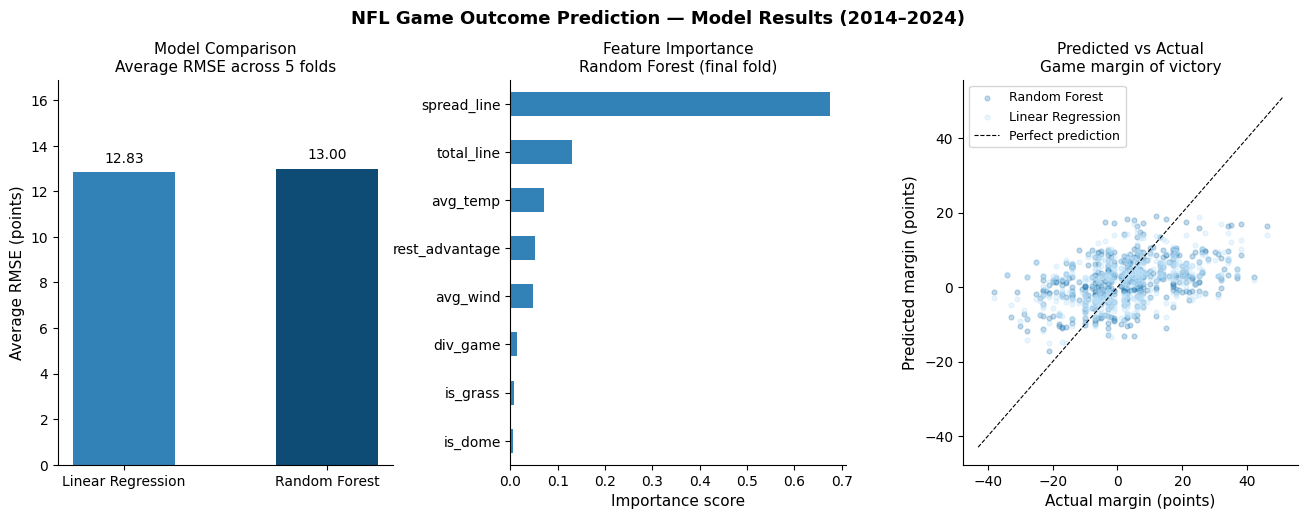

Figure saved as nfl_pipeline_results.png


In [ ]:
# Visualization rationale:
# Three-panel figure showing (1) model comparison, (2) feature importance
# from Random Forest, and (3) predicted vs actual for best model.
# Publication quality means clean axes, labeled clearly, no chartjunk.

try:
    # final folds for data viz
    X_train_f, X_test_f = X.iloc[train_idx], X.iloc[test_idx]
    y_train_f, y_test_f = y.iloc[train_idx], y.iloc[test_idx]
    X_train_sc_f = scaler.fit_transform(X_train_f)
    X_test_sc_f  = scaler.transform(X_test_f)

    lr = LinearRegression()
    rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
    lr.fit(X_train_sc_f, y_train_f)
    rf.fit(X_train_sc_f, y_train_f)
    lr_preds = lr.predict(X_test_sc_f)
    rf_preds = rf.predict(X_test_sc_f)

    # Feature importance from Random Forest
    importances = pd.Series(rf.feature_importances_, index=features).sort_values()

    # RMSE comparison data
    model_names = list(results.keys())
    avg_rmses   = [np.mean(results[m]['rmse']) for m in model_names]
    avg_r2s     = [np.mean(results[m]['r2'])   for m in model_names]

    # Build figure
    fig = plt.figure(figsize=(16, 5))
    fig.patch.set_facecolor('white')
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    # Panel 1 — Model comparison bar chart
    ax1 = fig.add_subplot(gs[0])
    bars = ax1.bar(model_names, avg_rmses, color=['#3282B8', '#0F4C75'], width=0.5)
    ax1.set_ylabel("Average RMSE (points)", fontsize=11)
    ax1.set_title("Model Comparison\nAverage RMSE across 5 folds", fontsize=11)
    ax1.set_ylim(0, max(avg_rmses) * 1.3)
    for bar, val in zip(bars, avg_rmses):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # Panel 2 — Feature importance
    ax2 = fig.add_subplot(gs[1])
    importances.plot(kind='barh', ax=ax2, color='#3282B8')
    ax2.set_title("Feature Importance\nRandom Forest (final fold)", fontsize=11)
    ax2.set_xlabel("Importance score", fontsize=11)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Panel 3 — Predicted vs actual
    ax3 = fig.add_subplot(gs[2])
    ax3.scatter(y_test_f, rf_preds, alpha=0.3, s=12, color='#3282B8', label='Random Forest')
    ax3.scatter(y_test_f, lr_preds, alpha=0.3, s=12, color='#BBE1FA', label='Linear Regression')
    lims = [min(y_test_f.min(), rf_preds.min()) - 5,
            max(y_test_f.max(), rf_preds.max()) + 5]
    ax3.plot(lims, lims, 'k--', linewidth=0.8, label='Perfect prediction')
    ax3.set_xlabel("Actual margin (points)", fontsize=11)
    ax3.set_ylabel("Predicted margin (points)", fontsize=11)
    ax3.set_title("Predicted vs Actual\nGame margin of victory", fontsize=11)
    ax3.legend(fontsize=9)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    plt.suptitle("NFL Game Outcome Prediction — Model Results (2014–2024)",
                 fontsize=13, fontweight='bold', y=1.02)

    plt.savefig("nfl_pipeline_results.png", dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print("Figure saved as nfl_pipeline_results.png")
    logging.info("Visualization saved successfully")

except Exception as e:
    logging.error(f"Error in visualization: {e}")
    raise

In [ ]:
print("""
## Visualization Rationale

The three-panel figure was used to show a story in essentially one glance:

Panel 1 (Model Comparison): A simple bar chart comparing average RMSE
across both models. RMSE is in points, making it directly interpretable
— an RMSE of 13 means predictions are off by 13 points on average.

Panel 2 (Feature Importance): Shows which variables the Random Forest
relied on most which helps answer the main question of the project
ie. which factors drive NFL outcomes the most? If spread_line dominates, it
confirms Vegas is hard to beat. If rest_advantage or weather features
rank highly, it suggests exploitable market inefficiencies.

Panel 3 (Predicted vs Actual): A scatter plot showing how well
predictions track reality. A perfect model would lie on the diagonal.
The spread of points around the diagonal shows irreducible variance —
NFL games have inherent unpredictability that no model can eliminate.
""")
logging.info("Pipeline complete")


## Visualization Rationale

The three-panel figure was chosen to tell a complete story in one view:

Panel 1 (Model Comparison): A simple bar chart comparing average RMSE
across both models. RMSE is in points, making it directly interpretable
— an RMSE of 13 means predictions are off by 13 points on average.

Panel 2 (Feature Importance): Shows which variables the Random Forest
relied on most. This directly answers the project's core question —
what factors drive NFL game outcomes? If spread_line dominates, it
confirms Vegas is hard to beat. If rest_advantage or weather features
rank highly, it suggests exploitable market inefficiencies.

Panel 3 (Predicted vs Actual): A scatter plot showing how well
predictions track reality. A perfect model would lie on the diagonal.
The spread of points around the diagonal shows irreducible variance —
NFL games have inherent unpredictability that no model can eliminate.

Design decisions: white background, minimal spines, consistent blue
color pale